In [1]:

%matplotlib inline
%load_ext autoreload
%autoreload 2
# %matplotlib tk


import os
import sys
# sys.path.append(os.environ['HOME'] + "/repos/dataengine/")
# sys.path.append(os.environ['HOME'] + "/repos/dataengine/visualizers/")

## https://github.com/dvlab-research/ECCV22-P3AFormer-Tracking-Objects-as-Pixel-wise-Distributions/tree/main

# Install CUDA
# https://developer.nvidia.com/cuda-11-8-0-download-archive?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=22.04&target_type=deb_network
# wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/cuda-keyring_1.0-1_all.deb
# sudo dpkg -i cuda-keyring_1.0-1_all.deb
# sudo apt-get update
# sudo apt-get -y install cuda-12-1
# torch:
# https://pytorch.org/get-started/locally/
# pip3 install torch==2.2.0 torchvision==0.17.0 (supports CUDA 11-8 and 12-1)

# pip3 install Pillow==7.1 mypy-extensions
    
# Detectron2
# git clone https://github.com/facebookresearch/detectron2.git
# cd detectron2 
# python3 setup.py build develop --install-dir $HOME/.local/lib/python3.10/site-packages/

# P3AFormer
# git clone https://github.com/dvlab-research/ECCV22-P3AFormer-Tracking-Objects-as-Pixel-wise-Distributions.git
# cd ECCV22-P3AFormer-Tracking-Objects-as-Pixel-wise-Distributions
# pip3 install -r requirements.txt
# pip3 install gdown && pip3 install --upgrade gdown
# cd models/ops
# python3 setup.py build install --prefix $HOME/.local/lib/python3.10/site-packages/
# python3 setup.py install --prefix $HOME/.local/lib/python3.10/site-packages/


## MOT Datasets
# mkdir data
# cd data
# wget https://motchallenge.net/data/MOT17.zip
# wget https://motchallenge.net/data/MOT20.zip
# unzip MOT17.zip
# unzip MOT20.zip

## Convert data to COCO format
# bash preprocess/data_preprocess.sh

## COCO Pre-Training
# bash configs/standard/v100_mot17_coco.sh

## Tracking performance
# bash configs/standard/v100_test_mot17.sh

## Visualization
# sudo apt install ffmpeg frei0r-plugins 
# sudo apt install python3-tk
    

import matplotlib.pyplot as plt
import matplotlib.animation as animation

from dataengine.source import DataSources
from dataengine.buffer import DataBuffer

from rosbags.highlevel import AnyReader
from rosbags.serde import deserialize_cdr

import numpy as np
from pathlib import Path

from dataengine.visualizers.video_segment import VisTool

from IPython.display import display, Image, HTML

from matplotlib import pyplot as plt


ModuleNotFoundError: No module named 'dataengine'

In [ ]:

## ROS2 MOTS data

period = 0.1

## MOT17
file_path = os.environ['HOME'] + "/repos/ECCV22-P3AFormer-Tracking-Objects-as-Pixel-wise-Distributions/data/mot/test/MOT17-01-DPM/img1/*.jpg"

## AOT
# file_path = "/data/aot/Images/0001ba865c8e410e88609541b8f55ffc/*.png"

data = DataSources(file_path, period)


In [55]:

## Buffer class

## Depth of buffer as message count
buffer_depth = 300
buffer = DataBuffer(data, buffer_depth, use_db=True)


In [56]:

## Iterator class

print(list(buffer.get_topics()))

axis = list(buffer.get_topics())[0]
# iterator = DataIterator(buffer, axis)


['images']


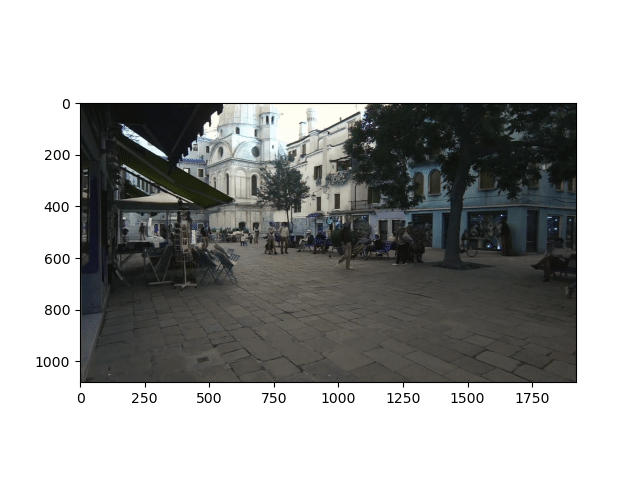

In [57]:

limit = 20

vis_tool = VisTool()

axis = list(buffer.get_topics())[0]

buffer.roll_buffer(axis)
# iterator = DataIterator(buffer, axis)

for buf, count in buffer.get_data():
    # if count == 10:
    #     iterator.reset()
    
    dat = buf[axis]['data'][-1]

    vis_tool.append_img(dat)

    if count >= limit:
        break

vis_tool.show_animation()



In [58]:

## MOTS example

## MOT17
# ground_truth = os.environ['HOME'] + "/repos/ECCV22-P3AFormer-Tracking-Objects-as-Pixel-wise-Distributions/data/MOT17/test/MOT17-01-DPM/det/det.txt"

## 
# ground_truth = os.environ['HOME'] + "/repos/monorepo/external_files/data/aot/ImageSets/groundtruth.csv"

# Example
# ,time,flight_id,img_name,frame,id,range_distance_m,is_above_horizon,size_width,size_height,gt_left,gt_top,gt_right,gt_bottom
# 684441,1554977349382218834,0001ba865c8e410e88609541b8f55ffc,15549773493822188340001ba865c8e410e88609541b8f55ffc.png,2,Helicopter1,1937.3400220866345,-1.0,2448,2048,1453.74418605,1067.46511628,1459.74418605,1073.46511628
# 684442,1554977349483260352,0001ba865c8e410e88609541b8f55ffc,15549773494832603520001ba865c8e410e88609541b8f55ffc.png,3,Helicopter1,1931.8630121946073,-1.0,2448,2048,1455.60465116,1063.97674419,1461.60465116,1069.97674419



In [2]:


## TODO: TileDB backend!


axis = list(buffer.get_topics())[0]

print("axis: ", axis)

buffer.reset()
buffer.roll_buffer(axis)


buffer.load_data_db(axis)



NameError: name 'buffer' is not defined

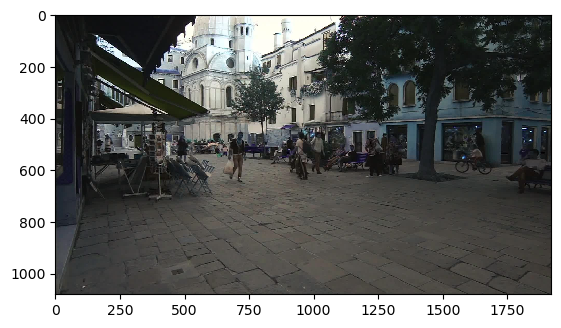

In [60]:


# print(buffer[400].shape)
# print("counter: ", buffer.counters)
# plt.imshow(buffer[400], interpolation='nearest')
# plt.show()


vis_tool = VisTool()
vis_tool.show(buffer[150])



In [ ]:


## TODO: Run P3AFormer!!!


## TODO: need container with PyTorch==1.10, Detectron2 installed


# train:
# bash configs/standard/v100_mot17_fine_tune_mot17.sh

# test:
# bash configs/standard/v100_test_mot17.sh


## TODO: edit ./configs/standard/v100_test_mot17.sh

# sys.path.append(os.environ['HOME'] + "/repos/ECCV22-P3AFormer-Tracking-Objects-as-Pixel-wise-Distributions/models/ops/")




In [ ]:


# TODO: put visualizer tools in iterator class???
# hide for loop
# init iterator with VisTool
# reuse VisTool, don't have separate visualizers???


# TODO: make it possible for user to define transformation methods in notebook
# separately? as override of class method???


## TODO: give interface to user to write data to db, add ground truth and inference results
# then they can query and analyze difference, write functions here to compare

